# Saudi Digital Concierge — Data Exploration
## Source 7: Entertainment in Saudi Arabia (Kaggle)

**File:** `data/raw/entertainment/Entertainment_KSA.csv`
**Purpose:** entertainment places — names, ratings, review counts, genre/category, location.

This dataset is scraped-style (Google-Maps-like) and **noticeably messier** than the
official sources. This notebook profiles it, quantifies the data-quality problems
(column misalignment, non-numeric ratings, parenthesised review counts, non-Saudi rows),
and ends with concrete cleaning steps.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CSV = BASE / "data" / "raw" / "entertainment" / "Entertainment_KSA.csv"

df = pd.read_csv(CSV)
print("Shape:", df.shape)
df.head()

Shape: (564, 7)


,Unnamed: 0,name,rating,review_count,genre,location,best_comment
0,0,المسرح الروماني | Roman Theater,4.1,(151),Performing arts theater,Al Uqayr Saudi Arabia,NaN
1,1,Maraya,4.6,(1.1T),Concert hall,Al Atheeb Saudi Arabia,"""Also the theater is another level of perfecti..."
2,2,"Novo Cinemas, Seef Mall",4.3,(801),Movie theater,"Muharraq, Bahrain · In Seef Mall - Arad, Muharraq","""The theater was comfortable and the screening..."
3,3,Education Department Theater,4.0,(169),Performing arts theater,NaN,"""Screen size is good enough."""
4,4,Muvi Cinemas - Jubail Mall,4.3,(871),Movie theater,Al Jubail Saudi Arabia · In Cenomi Al Jubail Mall,NaN


## 1. Schema & overview
`Unnamed: 0` is just a row index. The remaining columns:

| Column | Meaning |
| ------ | ------- |
| `name` | Venue name (bilingual: Arabic \| English) |
| `rating` | Average star rating (should be numeric) |
| `review_count` | Number of reviews, e.g. `(151)`, `(1.1T)` |
| `genre` | Category / type of venue |
| `location` | Free-text location, e.g. `Riyadh Saudi Arabia · In Kingdom Centre` |
| `best_comment` | A representative review snippet |

In [2]:
df = df.rename(columns={"Unnamed: 0": "idx"})
df.info()
print("\nExact duplicate rows:", df.duplicated(subset=[c for c in df.columns if c!='idx']).sum())
print("\nMissing values:")
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 564 entries, 0 to 563
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   idx           564 non-null    int64
 1   name          559 non-null    str  
 2   rating        564 non-null    str  
 3   review_count  562 non-null    str  
 4   genre         541 non-null    str  
 5   location      539 non-null    str  
 6   best_comment  342 non-null    str  
dtypes: int64(1), str(6)
memory usage: 31.0 KB

Exact duplicate rows: 243

Missing values:


idx               0
name              5
rating            0
review_count      2
genre            23
location         25
best_comment    222
dtype: int64

## 2. Data-quality issue #1 — column misalignment
Some rows are shifted: `rating` holds text like `"No reviews · Movie theater"` or
`"Saudi Arabia"`, `review_count` holds a city name, and `genre` holds a price symbol
(`₹`). These come from unquoted commas in the source scrape.

In [3]:
rating_num = pd.to_numeric(df["rating"], errors="coerce")
bad_rating = df[rating_num.isna()]
print(f"Rows where 'rating' is NOT numeric (misaligned/no-reviews): {len(bad_rating)}")
print("\nExamples of bad 'rating' values:")
print(bad_rating["rating"].value_counts().head(10).to_string())
print("\nA few misaligned rows:")
bad_rating[["name","rating","review_count","genre","location"]].head(5)

Rows where 'rating' is NOT numeric (misaligned/no-reviews): 24

Examples of bad 'rating' values:
rating
No reviews · Tourist attraction    13
No reviews · Movie theater          2
No reviews · Amphitheater           2
No reviews · IMAX theater           2
Saudi Arabia                        2
No reviews · Drama theater          1
No reviews · Restaurant             1
No reviews · School                 1

A few misaligned rows:


,name,rating,review_count,genre,location
56,Hayy Cinema (سينما حي),No reviews · Movie theater,Jeddah Saudi Arabia,NaN,NaN
66,Hayy Cinema (سينما حي),No reviews · Movie theater,Jeddah Saudi Arabia,NaN,NaN
132,College of Science Theatre,No reviews · Amphitheater,Saudi Arabia,"In Northern Border University, Main Campus",NaN
135,TSCK IMAX,No reviews · IMAX theater,"Salmiya, Kuwait",NaN,NaN
145,TSCK IMAX,No reviews · IMAX theater,"Salmiya, Kuwait",NaN,NaN


## 3. Ratings (parsed to numeric)

Valid numeric ratings: 540 / 564
count    540.00
mean       4.21
std        0.39
min        2.50
25%        4.00
50%        4.20
75%        4.50
max        5.00


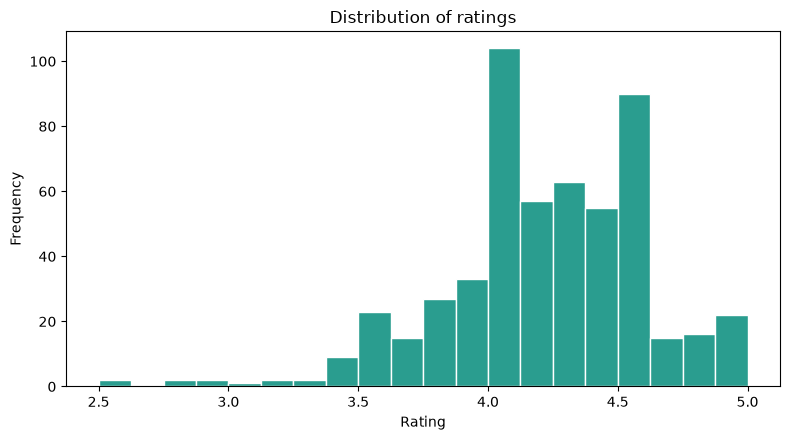

In [4]:
df["rating_num"] = pd.to_numeric(df["rating"], errors="coerce")
print("Valid numeric ratings:", df["rating_num"].notna().sum(), "/", len(df))
print(df["rating_num"].describe().round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 4.5))
df["rating_num"].plot(kind="hist", bins=20, ax=ax, color="#2a9d8f", edgecolor="white")
ax.set_title("Distribution of ratings")
ax.set_xlabel("Rating")
plt.tight_layout()
plt.show()

## 4. Review counts (parsed)
Values look like `(151)` or `(1.1T)`. Strip the parentheses and expand the `K`/`T`/`M`
suffixes (`T` = thousand here).

In [5]:
def parse_review_count(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().strip("()").strip()
    m = re.match(r"([\d.]+)\s*([KkMmTt]?)", s)
    if not m:
        return np.nan
    val = float(m.group(1))
    mult = {"": 1, "K": 1e3, "T": 1e3, "M": 1e6}[m.group(2).upper()]
    return val * mult

df["review_count_num"] = df["review_count"].map(parse_review_count)
print("Parsed review counts:", df["review_count_num"].notna().sum(), "/", len(df))
print(df["review_count_num"].describe().round(0).to_string())

Parsed review counts: 540 / 564
count      540.0
mean      1770.0
std       4227.0
min          1.0
25%         73.0
50%        458.0
75%       1700.0
max      36000.0


## 5. Location → country & city
The file is named *KSA* but contains a few non-Saudi venues (Bahrain, Kuwait). Extract a
country and a city so non-Saudi rows can be filtered and cities harmonised.

In [6]:
loc = df["location"].fillna("")
df["country"] = np.select(
    [loc.str.contains("Saudi Arabia"), loc.str.contains("Bahrain"),
     loc.str.contains("Kuwait"), loc.eq("")],
    ["Saudi Arabia", "Bahrain", "Kuwait", "Unknown"],
    default="Other",
)
df["city"] = (loc.str.split("·").str[0]
                 .str.replace("Saudi Arabia", "", regex=False).str.strip())

print("Country distribution:")
print(df["country"].value_counts(dropna=False).to_string())
print("\nTop cities:")
print(df.loc[df["city"] != "", "city"].value_counts().head(15).to_string())

Country distribution:
country
Saudi Arabia    525
Unknown          25
Bahrain           7
Other             7

Top cities:
city
Riyadh                      292
Jeddah                       37
Dammam                       15
Al Khobar                    14
Buraydah                      8
Hail                          8
Dhahran                       6
Abha                          6
Al-Muzahmiya                  6
Diriyah                       5
Tabuk                         4
Taif                          4
Jazan                         4
Unayzah                       4
Al Madinah Al Munawwarah      4


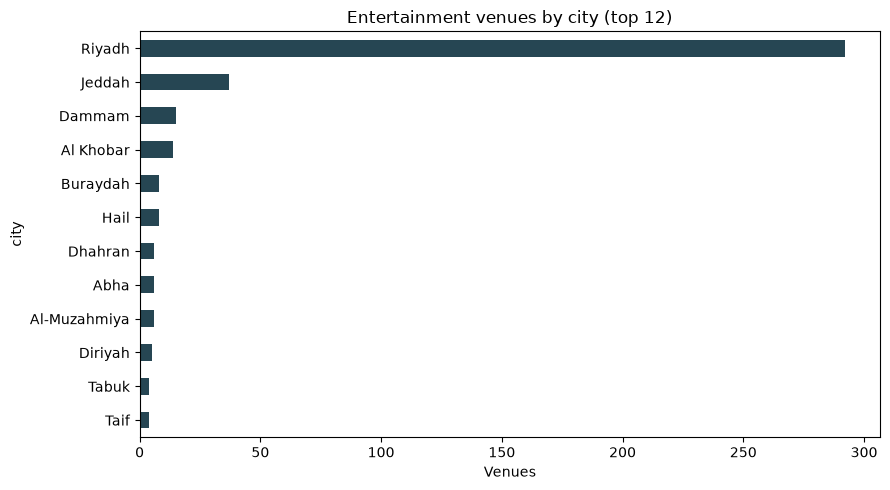

In [7]:
top_cities = df.loc[df['city'] != '', 'city'].value_counts().head(12)
fig, ax = plt.subplots(figsize=(9, 5))
top_cities.plot(kind="barh", ax=ax, color="#264653")
ax.invert_yaxis()
ax.set_title("Entertainment venues by city (top 12)")
ax.set_xlabel("Venues")
plt.tight_layout()
plt.show()

## 6. Genres / categories
Strip whitespace; note contamination (price symbols like `₹`, or leaked `In <place>`
location fragments) from the misaligned rows.

Contaminated genre values (price symbols / location leaks): 18

Top genres:
genre_clean
Tourist attraction             132
Movie theater                  128
Amusement center                57
Park                            23
Children's amusement center     21
Escape room center              20
Performing arts theater         16
Theme park                      13
Amusement park                  10
Garden                          10
Hiking area                      8
Concert hall                     7


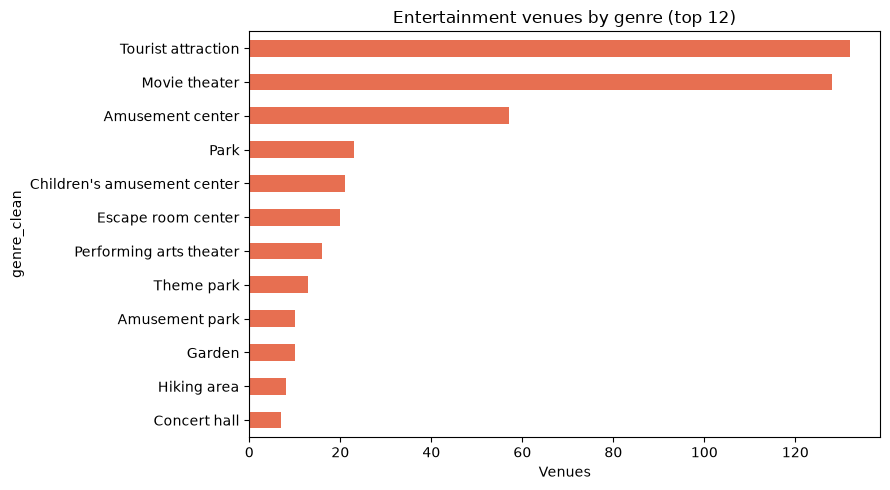

In [8]:
df["genre_clean"] = df["genre"].fillna("").str.strip()
contaminated = df["genre_clean"].str.match(r"^[₹$]+$") | df["genre_clean"].str.startswith("In ")
print("Contaminated genre values (price symbols / location leaks):", int(contaminated.sum()))

top_genres = df.loc[~contaminated & (df["genre_clean"] != ""), "genre_clean"].value_counts().head(12)
print("\nTop genres:")
print(top_genres.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
top_genres.plot(kind="barh", ax=ax, color="#e76f51")
ax.invert_yaxis()
ax.set_title("Entertainment venues by genre (top 12)")
ax.set_xlabel("Venues")
plt.tight_layout()
plt.show()

## 7. Average rating by genre (top genres)

In [9]:
valid = df[df["rating_num"].notna() & (df["genre_clean"] != "")]
top10 = valid["genre_clean"].value_counts().head(10).index
by_genre = (valid[valid["genre_clean"].isin(top10)]
            .groupby("genre_clean")
            .agg(avg_rating=("rating_num", "mean"), n=("rating_num", "size"))
            .sort_values("avg_rating", ascending=False))
by_genre.round(2)

,avg_rating,n
genre_clean,,
Escape room center,4.56,20
Tourist attraction,4.31,132
Park,4.23,23
Children's amusement center,4.21,21
Movie theater,4.12,128
Performing arts theater,4.11,16
Theme park,3.98,13
Amusement center,3.92,57
Garden,3.92,10


## 8. Duplicates
No exact duplicate rows, but many venue **names repeat** — these are mostly legitimate
chain branches (Muvi, VOX, Sparky's) at different locations, plus some naming
inconsistency (with/without the Arabic half).

In [10]:
print("Exact duplicate rows:", df.drop(columns='idx').duplicated().sum())
print("Unique names:", df['name'].nunique(), "/", len(df))
print("\nMost repeated names (chains):")
print(df['name'].value_counts().head(8).to_string())

Exact duplicate rows: 243
Unique names: 271 / 564

Most repeated names (chains):
name
Muvi Cinemas | موڤي سينما    22
Sparky's | سباركيز            8
Sparky's                      6
The Escape Hotel              5
VOX Cinemas                   4
Saffori Land                  4
سفوري لاند | Safforiland      4
Sky Zone                      4


## 9. Missing values

In [11]:
miss = pd.DataFrame({
    "missing": df[['name','rating','review_count','genre','location','best_comment']].isna().sum(),
    "missing_%": (df[['name','rating','review_count','genre','location','best_comment']]
                  .isna().mean()*100).round(1),
}).sort_values("missing", ascending=False)
miss

,missing,missing_%
best_comment,222,39.4
location,25,4.4
genre,23,4.1
name,5,0.9
review_count,2,0.4
rating,0,0.0


## 10. Findings & cleaning recommendations

**Overview**
- **564 rows × 7 columns**. `Unnamed: 0` is a redundant index.
- Fields: `name` (bilingual), `rating`, `review_count`, `genre`, `location`, `best_comment`.
- No exact duplicate rows; 271 unique names (chains repeat legitimately).

**Data-quality issues (for `src/cleaning`)**
1. **Column misalignment (~24 rows)** — the biggest problem. `rating` holds text
   (`"No reviews · …"`, `"Saudi Arabia"`), `review_count` holds a city, `genre` holds a
   price symbol (`₹`). Caused by unquoted commas in the scrape. **Detect** these rows
   (rating not numeric) and either re-parse from `location`/`best_comment` or drop them.
2. **`rating` is text** → cast to float; ~24 non-numeric (misaligned or "No reviews").
3. **`review_count` is parenthesised** with `K`/`T`/`M` suffixes (`T` = thousand) →
   parse to integer (range ~1–36,000).
4. **Non-Saudi rows** — ~14 venues in Bahrain/Kuwait despite the "KSA" name → filter to
   `country == "Saudi Arabia"`.
5. **`genre` needs trimming** (leading spaces) and removal of contaminated values
   (price symbols, `In <place>` leaks).
6. **`location` is free text** → extract a canonical city (Riyadh dominates ≈ 52%) and
   map to the city/province key used by the other sources.
7. **`best_comment` ~39% missing** — keep as optional enrichment, not a key field.
8. **Name inconsistency** — same venue sometimes with/without the Arabic half; normalise
   before dedup if needed.

**Concierge relevance:** high — real venues with ratings, categories and cities answer
"fun things to do in \<city\>" directly, and complement the events source. But it needs
the most cleaning of the tabular sources. After cleaning, keep Saudi rows with a valid
rating and a mapped city; embed name + genre + city + rating (+ best_comment) into the
vector store.

**Next:** implement the cleaning above → tidy `entertainment` table in `data/processed/`.